# Sentiment Analysis with a Transformer from Scratch

We **build and train** a small transformer using only our task data. That means we must define:

- **How text becomes numbers** (our own tokenizer and vocabulary)
- **How the model is structured** (embeddings, positions, attention, classifier)
- **How it learns** (loss and optimizer)

---
## 1. Imports and device

We use PyTorch for the model and training, and HuggingFace `datasets` only to load IMDB (same as the reference notebook). We do **not** use the `transformers` library here; no pretrained tokenizer or model. The **device** (CPU/GPU/MPS) is set once so we can move the model and data to it in every later step.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random
import re
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


---
## 2. Load dataset

We load IMDB and take the **same subsets**: 2000 training and 1000 test examples, with **seed=42** for shuffling. Using the same data and seed as the BERT notebook lets us compare the two approaches fairly.

In [56]:
dataset = load_dataset("imdb")
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(1000))

print("Train size:", len(train_dataset), "Test size:", len(test_dataset))
print("Sample:", train_dataset[0]["text"][:200], "...", "Label:", train_dataset[0]["label"])

Train size: 2000 Test size: 1000
Sample: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F ... Label: 1


---
## 3. Simple tokenizer and vocabulary (from scratch)

We do **not** use a pretrained tokenizer. We build a **word-level** tokenizer and vocabulary from the **training set only** (so the model and tokenizer only see train data until evaluation). This block must run **after** we have `train_dataset` and **before** we convert any text to IDs.

- **Tokenize**: Lowercase, split on non-alphanumeric, keep words (and numbers/apostrophes).
- **Vocabulary**: Map each word to an integer ID. We reserve index **0** for padding and **1** for unknown words; the rest are the most frequent words in the training set (up to 20,000).
- **Max length**: 256 tokens per review (same as the BERT notebook) so we can compare fairly and batch easily.

In [57]:
PAD_ID = 0
UNK_ID = 1
MAX_LEN = 256
VOCAB_SIZE = 20000

def simple_tokenize(text):
    text = text.lower().strip()
    tokens = re.findall(r"[a-z0-9']+", text)
    return tokens if tokens else [""]

def build_vocab(dataset, vocab_size=VOCAB_SIZE):
    counter = Counter()
    for ex in dataset:
        counter.update(simple_tokenize(ex["text"]))
    most_common = counter.most_common(vocab_size - 2)
    word2id = {"<pad>": PAD_ID, "<unk>": UNK_ID}
    for w, _ in most_common:
        word2id[w] = len(word2id)
    return word2id

word2id = build_vocab(train_dataset)
print("Vocabulary size:", len(word2id))

Vocabulary size: 20000


In [ ]:
def text_to_ids(text, word2id, max_len=MAX_LEN):
    # Split text into individual tokens/words
    tokens = simple_tokenize(text)
    # Map tokens to IDs; use UNK_ID for unknown words and truncate to max_len
    ids = [word2id.get(t, UNK_ID) for t in tokens[:max_len]]
    # Calculate necessary padding to ensure all sequences are the same length
    padding = [PAD_ID] * (max_len - len(ids))
    return ids + padding

def get_attention_mask(ids):
    # Create a mask: 1 for actual data tokens, 0 for padding tokens
    return [1 if x != PAD_ID else 0 for x in ids]

# --- Dataset Processing ---

# Convert raw training text into fixed-length integer IDs
train_ids = [text_to_ids(ex["text"], word2id) for ex in train_dataset]
# Generate attention masks to tell the model which IDs to ignore
train_masks = [get_attention_mask(ids) for ids in train_ids]
# Extract training labels
train_labels = [ex["label"] for ex in train_dataset]

# Repeat the same preprocessing steps for the test dataset
test_ids = [text_to_ids(ex["text"], word2id) for ex in test_dataset]
test_masks = [get_attention_mask(ids) for ids in test_ids]
test_labels = [ex["label"] for ex in test_dataset]

# Zip the components together into a list of tuples for easier iteration/batching
train_data = list(zip(train_ids, train_masks, train_labels))
test_data = list(zip(test_ids, test_masks, test_labels))

# Sanity check: ensure the first training example is padded correctly and has a label
print("First train input length:", len(train_ids[0]), "Label:", train_labels[0])

First train input length: 256 Label: 1


---
## 4. PyTorch Dataset and DataLoader

We need to feed the model in **batches** during training. PyTorch’s `DataLoader` expects a `Dataset` that returns one example per index. So we **first** wrap `train_data` and `test_data` (the lists of (ids, mask, label) we built above) in a small `Dataset` class that converts each triple to tensors. **Then** we create DataLoaders with `batch_size=8` (same as the BERT notebook) so each training step gets 8 examples at once.


In [ ]:
# Custom Dataset class to wrap our processed IMDB data for PyTorch
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        # Store the zipped list of (ids, masks, labels)
        self.data = data

    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.data)

    def __getitem__(self, idx):
        # Unpack the specific sample at the given index
        ids, mask, label = self.data[idx]
        
        # Return a dictionary of tensors; long type is required for embedding lookups and loss functions
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
        }

# Instantiate the custom datasets
train_ds = IMDBDataset(train_data)
test_ds = IMDBDataset(test_data)

# --- DataLoaders ---

# Create a training loader that shuffles data each epoch to prevent the model from learning order bias
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True)

# Create a testing loader (shuffling isn't necessary for evaluation)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=8)

---
## 5. Transformer model from scratch

The order of operations in the network is: **embedding → add position → transformer encoder → take first position → linear to 2 classes**. We use PyTorch’s built-in `nn.TransformerEncoderLayer` so we don’t reimplement attention by hand; we only define how inputs are prepared and how we get a single vector for classification.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create a matrix of [max_len, d_model] filled with zeros
        pe = torch.zeros(max_len, d_model)
        # Sequence of positions [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # Compute the geometric progression for wavelengths (the "div_term")
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        # Apply sine to even indices (0, 2, 4...) and cosine to odd indices (1, 3, 5...)
        # This allows the model to learn relative positions via linear functions
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Register as a buffer so it's saved with the model but not updated by the optimizer
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # Add the positional encoding to the token embeddings
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class TransformerForSentiment(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, num_classes=2, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        # Standard embedding layer; ignore padding tokens during gradient updates
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        
        # Define a single Transformer layer (Multi-head attention + Feedforward)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True, # Keeps the shape as (batch, seq, feature)
            norm_first=False,
        )
        # Stack multiple encoder layers
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        
        # Final linear layer to project the hidden state to class logits (e.g., Positive/Negative)
        self.classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model

    def forward(self, input_ids, attention_mask):
        # 1. Convert token IDs to dense vectors
        x = self.embedding(input_ids)
        # 2. Inject order information into the sequence
        x = self.pos_encoding(x)
        
        # 3. Create a boolean mask where True = "ignore this token" (padding)
        padding_mask = (attention_mask == 0)
        
        # 4. Pass through the Transformer stacks
        x = self.transformer(x, mask=None, src_key_padding_mask=padding_mask)
        
        # 5. Pooling: Use the representation of the FIRST token (like a [CLS] token) for classification
        cls_output = x[:, 0, :]
        
        # 6. Output the logits for each class
        logits = self.classifier(cls_output)
        return logits

In [61]:
vocab_size = len(word2id)
model = TransformerForSentiment(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, num_classes=2, max_len=MAX_LEN).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 2,825,218


---
## 6. Training loop

We **minimize cross-entropy loss** between the model’s logits and the true labels by updating all parameters with Adam. This block uses `train_loader` (from Section 4) and the `model` we just created. We run for **2 epochs** (same as the BERT notebook) so the comparison is fair.

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 2
losses = []

model.train()
for epoch in range(epochs):
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs} done")

print("Training complete.")

Epoch 1/2 done
Epoch 2/2 done
Training complete.


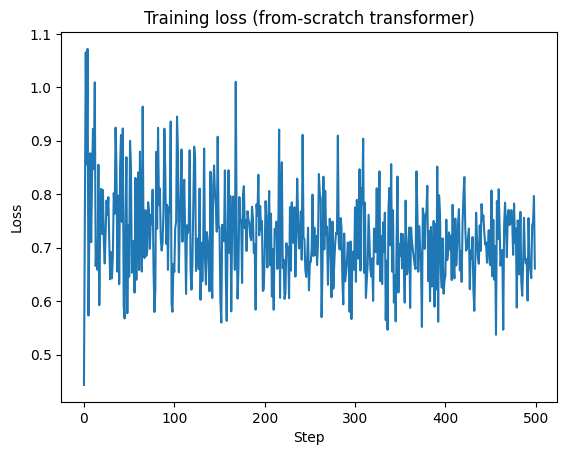

In [63]:
plt.figure()
plt.plot(losses)
plt.title("Training loss (from-scratch transformer)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

---
## 7. Evaluation

We measure how well the model **generalizes** by evaluating on the **test set** (data the model never trained on). We use **accuracy**: the fraction of test examples where the predicted class matches the true label. This block runs **after** training so we use the updated weights; we do **not** update the model here. We store the result in `accuracy_from_scratch` so the comparison cell at the end can use it.

In [64]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(logits, dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy_from_scratch = correct / total
print(f"Test accuracy (from-scratch transformer): {accuracy_from_scratch:.4f} ({correct}/{total} correct)")

Test accuracy (from-scratch transformer): 0.5360 (536/1000 correct)


---
## 8. Predict on new text

We define a **helper function** that takes raw text, tokenizes it with our `word2id` and `text_to_ids`, runs one forward pass, and returns the predicted class (0 or 1) and confidence. This is the same idea as the BERT notebook’s user-input prediction: you can call this with any string (e.g. a new review) and get a sentiment label.

In [66]:
def predict_sentiment_from_scratch(text, model, word2id, device):
    model.eval()
    ids = text_to_ids(text, word2id)
    mask = get_attention_mask(ids)
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    attention_mask = torch.tensor([mask], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
    probs = torch.softmax(logits, dim=1)
    pred_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_id].item()
    return pred_id, confidence

sample = "This movie was amazing! I loved it."
pred, conf = predict_sentiment_from_scratch(sample, model, word2id, device)
print(f"Text: {sample}")
print(f"Prediction: {'Positive' if pred == 1 else 'Negative'}, Confidence: {conf:.2%}")

Text: This movie was amazing! I loved it.
Prediction: Positive, Confidence: 54.11%


In [ ]:
# Fill in BERT accuracy after running transformer_sentiment_analysis_notebook.ipynb
bert_accuracy = None  # e.g. 0.87
if bert_accuracy is not None:
    print(f"BERT test accuracy:        {bert_accuracy:.4f}")
    print(f"From-scratch test accuracy: {accuracy_from_scratch:.4f}")
    print(f"Difference:                {bert_accuracy - accuracy_from_scratch:+.4f}")
else:
    print(f"From-scratch accuracy (this run): {accuracy_from_scratch:.4f}")

Run transformer_sentiment_analysis_notebook.ipynb and set bert_accuracy above to compare.
From-scratch accuracy (this run): 0.5360
